In [2]:
import pandas as pd

data=pd.read_excel(r"C:\Users\Acer\Desktop\Data Analytics\Simulator\TATa data\Online Retail.xlsx")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
data['CustomerID'].isnull().sum()

np.int64(135080)

In [7]:
data['CustomerID'] = data['CustomerID'].fillna('Unknown')

In [8]:
data['Description']=data['Description'].fillna('No description')

In [9]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [ ]:
data['Revenue'] = data['UnitPrice'] * data['Quantity']
data['Revenue'].head(10)

In [ ]:
data['Revenue'].describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64


Top 10 Countries by Revenue:
Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


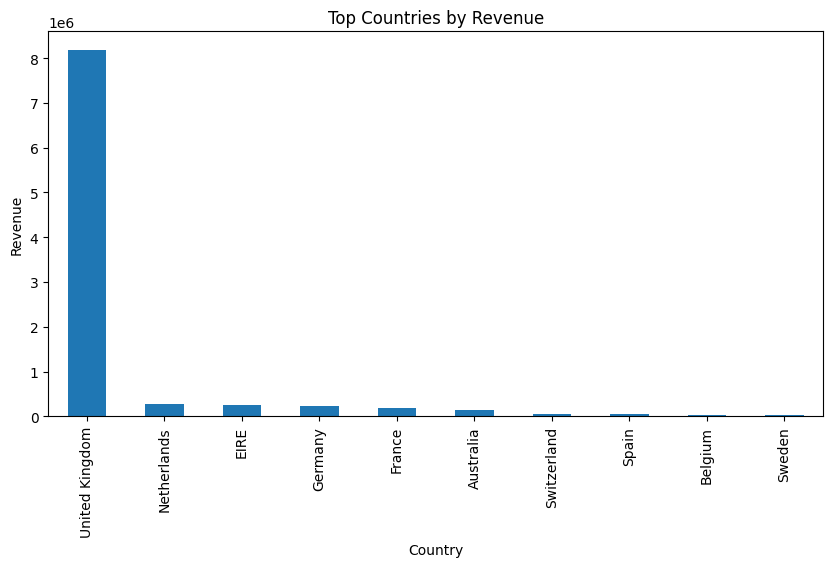

In [13]:
import matplotlib.pyplot as plt
country_sales = data.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print("\nTop 10 Countries by Revenue:")
print(country_sales.head(10))

# Plot
country_sales.head(10).plot(kind='bar', figsize=(10,5), title='Top Countries by Revenue')
plt.ylabel("Revenue")
plt.show()

In [14]:
product_sales = data.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

print("\nTop 10 Products:")
print(product_sales.head(10))

print("\nLowest 10 Products:")
print(product_sales.tail(10))


Top 10 Products:
Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

Lowest 10 Products:
Description
WOODEN BOX ADVENT CALENDAR           -45.700
CREAM SWEETHEART MAGAZINE RACK       -46.850
WHITE CHERRY LIGHTS                  -54.000
SAMPLES                            -3049.390
Discount                           -5696.220
Bank Charges                       -7175.639
CRUK Commission                    -7933.430
Adjust bad debt                   -11062.060
Manual                            -68671.640
AMAZON FEE            

In [15]:
customer_value = data.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

print("\nTop 10 Customers by Revenue:")
print(customer_value.head(10))


Top 10 Customers by Revenue:
CustomerID
Unknown    1447682.12
14646.0     279489.02
18102.0     256438.49
17450.0     187482.17
14911.0     132572.62
12415.0     123725.45
14156.0     113384.14
17511.0      88125.38
16684.0      65892.08
13694.0      62653.10
Name: Revenue, dtype: float64



Top 10 Countries by Revenue:
Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


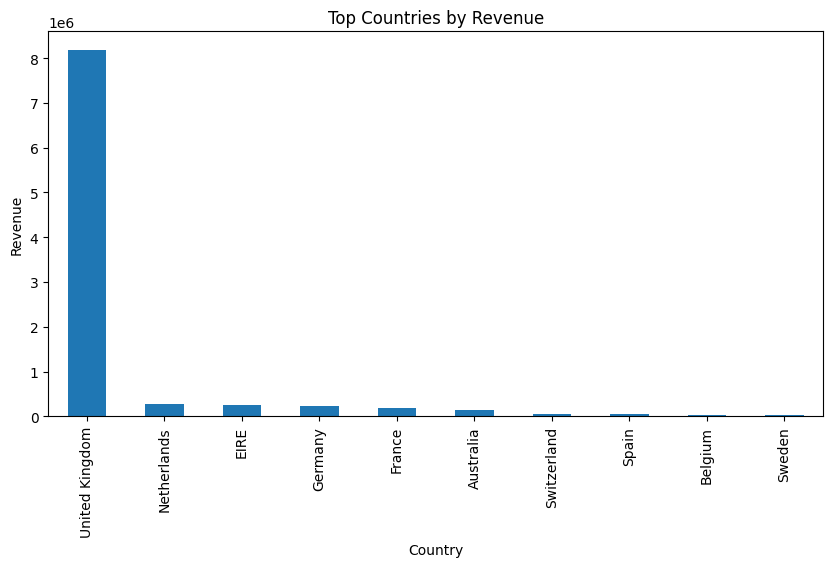


Top 10 Products:
Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

Lowest 10 Products:
Description
WOODEN BOX ADVENT CALENDAR           -45.700
CREAM SWEETHEART MAGAZINE RACK       -46.850
WHITE CHERRY LIGHTS                  -54.000
SAMPLES                            -3049.390
Discount                           -5696.220
Bank Charges                       -7175.639
CRUK Commission                    -7933.430
Adjust bad debt                   -11062.060
Manual                            -68671.640
AMAZON FEE            

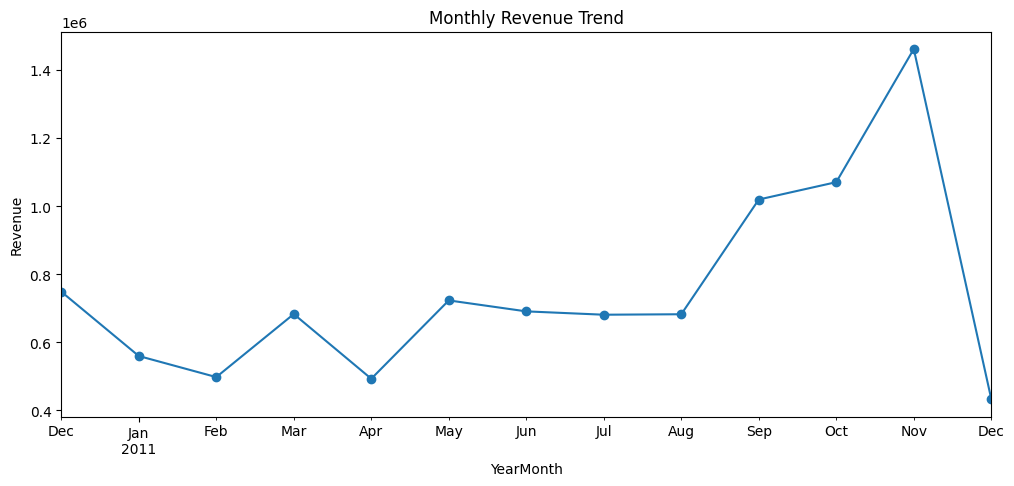


Top 10 Customers by Revenue:
CustomerID
Unknown    1447682.12
14646.0     279489.02
18102.0     256438.49
17450.0     187482.17
14911.0     132572.62
12415.0     123725.45
14156.0     113384.14
17511.0      88125.38
16684.0      65892.08
13694.0      62653.10
Name: Revenue, dtype: float64

Customer Spend Summary:
count    4.373000e+03
mean     2.229076e+03
std      2.335683e+04
min     -4.287630e+03
25%      2.934500e+02
50%      6.484100e+02
75%      1.612130e+03
max      1.447682e+06
Name: Revenue, dtype: float64

Customer Segments:
Revenue
Low       1458
High      1458
Medium    1457
Name: count, dtype: int64

Sample Product Bundles:
InvoiceNo
536365    [WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...
536366    [HAND WARMER UNION JACK, HAND WARMER RED POLKA...
536367    [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...
536368    [JAM MAKING SET WITH JARS, RED COAT RACK PARIS...
536369                           [BATH BUILDING BLOCK WORD]
536370    [ALARM CLOCK BAKELIKE PINK, ALARM 

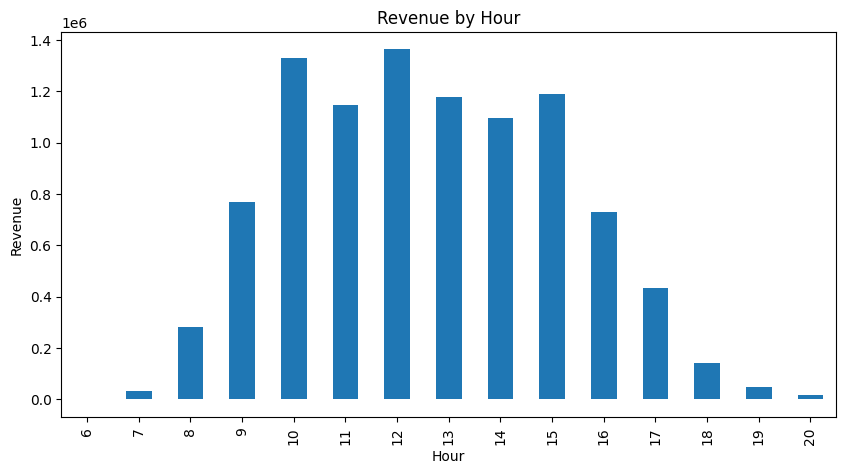


One-time Buyers: 1313
Repeat Buyers: 3060


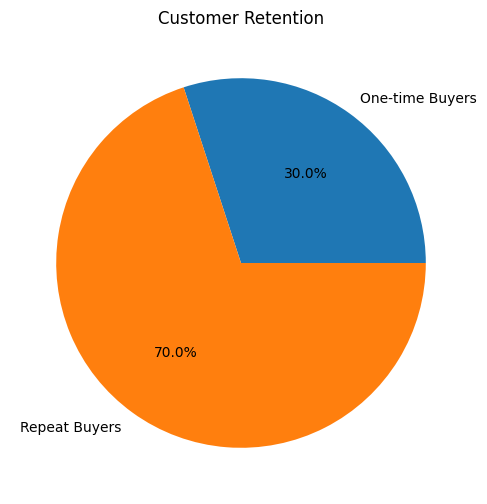

In [ ]:
# ==========================================================
# ONLINE RETAIL DATASET ANALYSIS
# Answers to CEO + CMO Questions
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns





# CEO QUESTIONS
# ==========================================================

# ----------------------------------------------------------
# CEO Q1: Which countries generate highest revenue?
# ----------------------------------------------------------
country_sales = data.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

print("\nTop 10 Countries by Revenue:")
print(country_sales.head(10))

# Plot
country_sales.head(10).plot(kind='bar', figsize=(10,5), title='Top Countries by Revenue')
plt.ylabel("Revenue")
plt.show()


# ----------------------------------------------------------
# CEO Q2: Top-selling and Lowest-performing Products
# ----------------------------------------------------------
product_sales = data.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

print("\nTop 10 Products:")
print(product_sales.head(10))

print("\nLowest 10 Products:")
print(product_sales.tail(10))


# ----------------------------------------------------------
# CEO Q3: Monthly Revenue Trend
# ----------------------------------------------------------
data['YearMonth'] = data['InvoiceDate'].dt.to_period('M')

monthly_sales = data.groupby('YearMonth')['Revenue'].sum()

print("\nMonthly Revenue Trend:")
print(monthly_sales)

monthly_sales.plot(figsize=(12,5), marker='o', title='Monthly Revenue Trend')
plt.ylabel("Revenue")
plt.show()


# ----------------------------------------------------------
# CEO Q4: Most Valuable Customers
# ----------------------------------------------------------
customer_value = data.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

print("\nTop 10 Customers by Revenue:")
print(customer_value.head(10))


# ==========================================================
# CMO QUESTIONS
# ==========================================================

# ----------------------------------------------------------
# CMO Q1: Customer Segments by Spending
# ----------------------------------------------------------
customer_spend = data.groupby('CustomerID')['Revenue'].sum()

print("\nCustomer Spend Summary:")
print(customer_spend.describe())

# Segment customers
customer_segment = pd.qcut(customer_spend, q=3, labels=['Low', 'Medium', 'High'])
print("\nCustomer Segments:")
print(customer_segment.value_counts())


# ----------------------------------------------------------
# CMO Q2: Products Bought Together (Bundling)
# ----------------------------------------------------------
basket = data.groupby('InvoiceNo')['Description'].apply(list)

print("\nSample Product Bundles:")
print(basket.head(10))


# ----------------------------------------------------------
# CMO Q3: Best Time for Purchases
# ----------------------------------------------------------
data['Hour'] = data['InvoiceDate'].dt.hour
data['DayName'] = data['InvoiceDate'].dt.day_name()

hour_sales = data.groupby('Hour')['Revenue'].sum()

print("\nRevenue by Hour:")
print(hour_sales)

hour_sales.plot(kind='bar', figsize=(10,5), title='Revenue by Hour')
plt.ylabel("Revenue")
plt.show()


# ----------------------------------------------------------
# CMO Q4: One-time vs Repeat Buyers
# ----------------------------------------------------------
customer_orders = data.groupby('CustomerID')['InvoiceNo'].nunique()
customer_orders.sum()

one_time = (customer_orders == 1).sum()
repeat = (customer_orders > 1).sum()

print("\nOne-time Buyers:", one_time)
print("Repeat Buyers:", repeat)

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie([one_time, repeat],
        labels=['One-time Buyers', 'Repeat Buyers'],
        autopct='%1.1f%%')
plt.title("Customer Retention")
plt.show()



In [18]:
basket = data.groupby('InvoiceNo')['Description'].apply(list)

print("\nSample Product Bundles:")
print(basket.head(10))


Sample Product Bundles:
InvoiceNo
536365    [WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...
536366    [HAND WARMER UNION JACK, HAND WARMER RED POLKA...
536367    [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...
536368    [JAM MAKING SET WITH JARS, RED COAT RACK PARIS...
536369                           [BATH BUILDING BLOCK WORD]
536370    [ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...
536371                    [PAPER CHAIN KIT 50'S CHRISTMAS ]
536372    [HAND WARMER RED POLKA DOT, HAND WARMER UNION ...
536373    [WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...
536374                         [VICTORIAN SEWING BOX LARGE]
Name: Description, dtype: object


In [19]:
data['Hour'] = data['InvoiceDate'].dt.hour
data['DayName'] = data['InvoiceDate'].dt.day_name()

hour_sales = data.groupby('Hour')['Revenue'].sum()

print("\nRevenue by Hour:")
print(hour_sales)


Revenue by Hour:
Hour
6        -497.350
7       31009.320
8      281840.860
9      766734.051
10    1329056.521
11    1147437.920
12    1362484.290
13    1177506.370
14    1095212.901
15    1189458.280
16     729140.820
17     435444.111
18     140574.480
19      46324.990
20      16020.370
Name: Revenue, dtype: float64


In [20]:
# Extract Hour
data['Hour'] = data['InvoiceDate'].dt.hour

# Revenue by Hour
hour_sales = data.groupby('Hour')['Revenue'].sum().reset_index()

# Find Best Hour
best_hour = hour_sales.loc[hour_sales['Revenue'].idxmax(), 'Hour']
best_revenue = hour_sales['Revenue'].max()

print(hour_sales)

# Convert Hour into Time Labels
def time_label(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

hour_sales['Time_Period'] = hour_sales['Hour'].apply(time_label)

# Revenue by Period
period_sales = hour_sales.groupby('Time_Period')['Revenue'].sum().sort_values(ascending=False)

print("\nRevenue by Time Period:")
print(period_sales)

# Best 3 Continuous Hours
top3 = hour_sales.sort_values(by='Revenue', ascending=False).head(3)

print("\nBest Sales Hours:")
print(top3[['Hour','Revenue']])

# Final Insight
print(f"\n📌 Peak sales hour is {best_hour}:00 with revenue {best_revenue:.2f}")

# Example Custom Insight
best_period = period_sales.idxmax()
print(f"📌 Overall best selling time period is {best_period}")

    Hour      Revenue
0      6     -497.350
1      7    31009.320
2      8   281840.860
3      9   766734.051
4     10  1329056.521
5     11  1147437.920
6     12  1362484.290
7     13  1177506.370
8     14  1095212.901
9     15  1189458.280
10    16   729140.820
11    17   435444.111
12    18   140574.480
13    19    46324.990
14    20    16020.370

Revenue by Time Period:
Time_Period
Afternoon    5553802.661
Morning      3555581.322
Evening       638363.951
Name: Revenue, dtype: float64

Best Sales Hours:
   Hour      Revenue
6    12  1362484.290
4    10  1329056.521
9    15  1189458.280

📌 Peak sales hour is 12:00 with revenue 1362484.29
📌 Overall best selling time period is Afternoon


In [24]:
customer_orders = data.groupby('CustomerID')['InvoiceNo'].nunique()

print(customer_orders.sum())

one_time = (customer_orders == 1).sum()
repeat = (customer_orders > 1).sum()

print("\nOne-time Buyers:", one_time)
print("Repeat Buyers:", repeat)



25900

One-time Buyers: 1313
Repeat Buyers: 3060
